# Machin!!


In [71]:
import scanpy as sc
import os
import matplotlib.pyplot as plt

In [72]:
# Load as cells x genes (transpose because genes are rows in gut.tsv)
data = sc.read_text(os.getcwd() + "\\gut.tsv", delimiter="\t").T
data.var_names_make_unique()

In [73]:
#filters
sc.pp.filter_cells(data, min_genes=200) # filter low-quality cells
sc.pp.filter_genes(data, min_cells=3)  # filter rare genes

In [74]:
#normalizing the data 
sc.pp.normalize_total(data,target_sum=10000)
sc.pp.log1p(data)

In [75]:
#clustering
sc.pp.pca(data)
sc.pp.neighbors(data)



In [76]:
sc.tl.leiden(data,resolution=0.1)

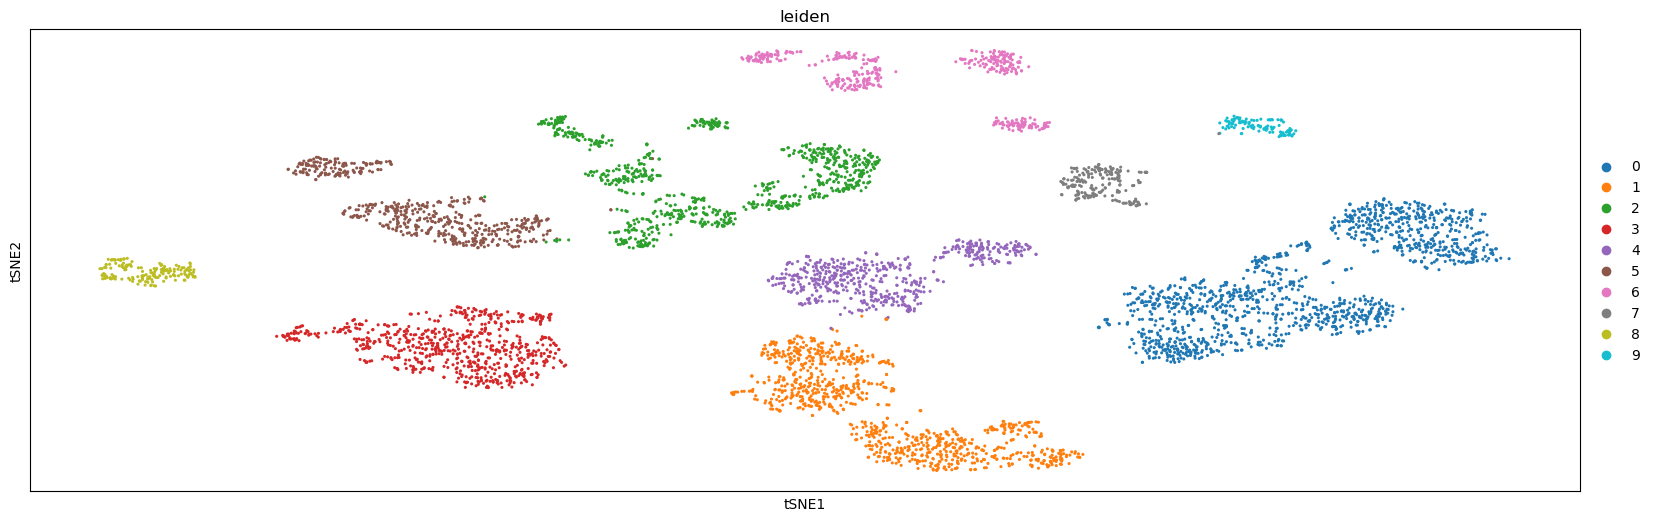

In [77]:
#t-sne
sc.tl.tsne(data)
#visulisation
sc.pl.tsne(data,color = "leiden")

In [78]:
sc.tl.rank_genes_groups(data, groupby="leiden")

In [79]:
result = sc.get.rank_genes_groups_df(data,group = None)
clusters = result["group"].unique()
top_genes = []
for c in clusters:
    top_genes.append(result[result["group"] == c].sort_values(by = "logfoldchanges",ascending = False)["names"].iloc[0])

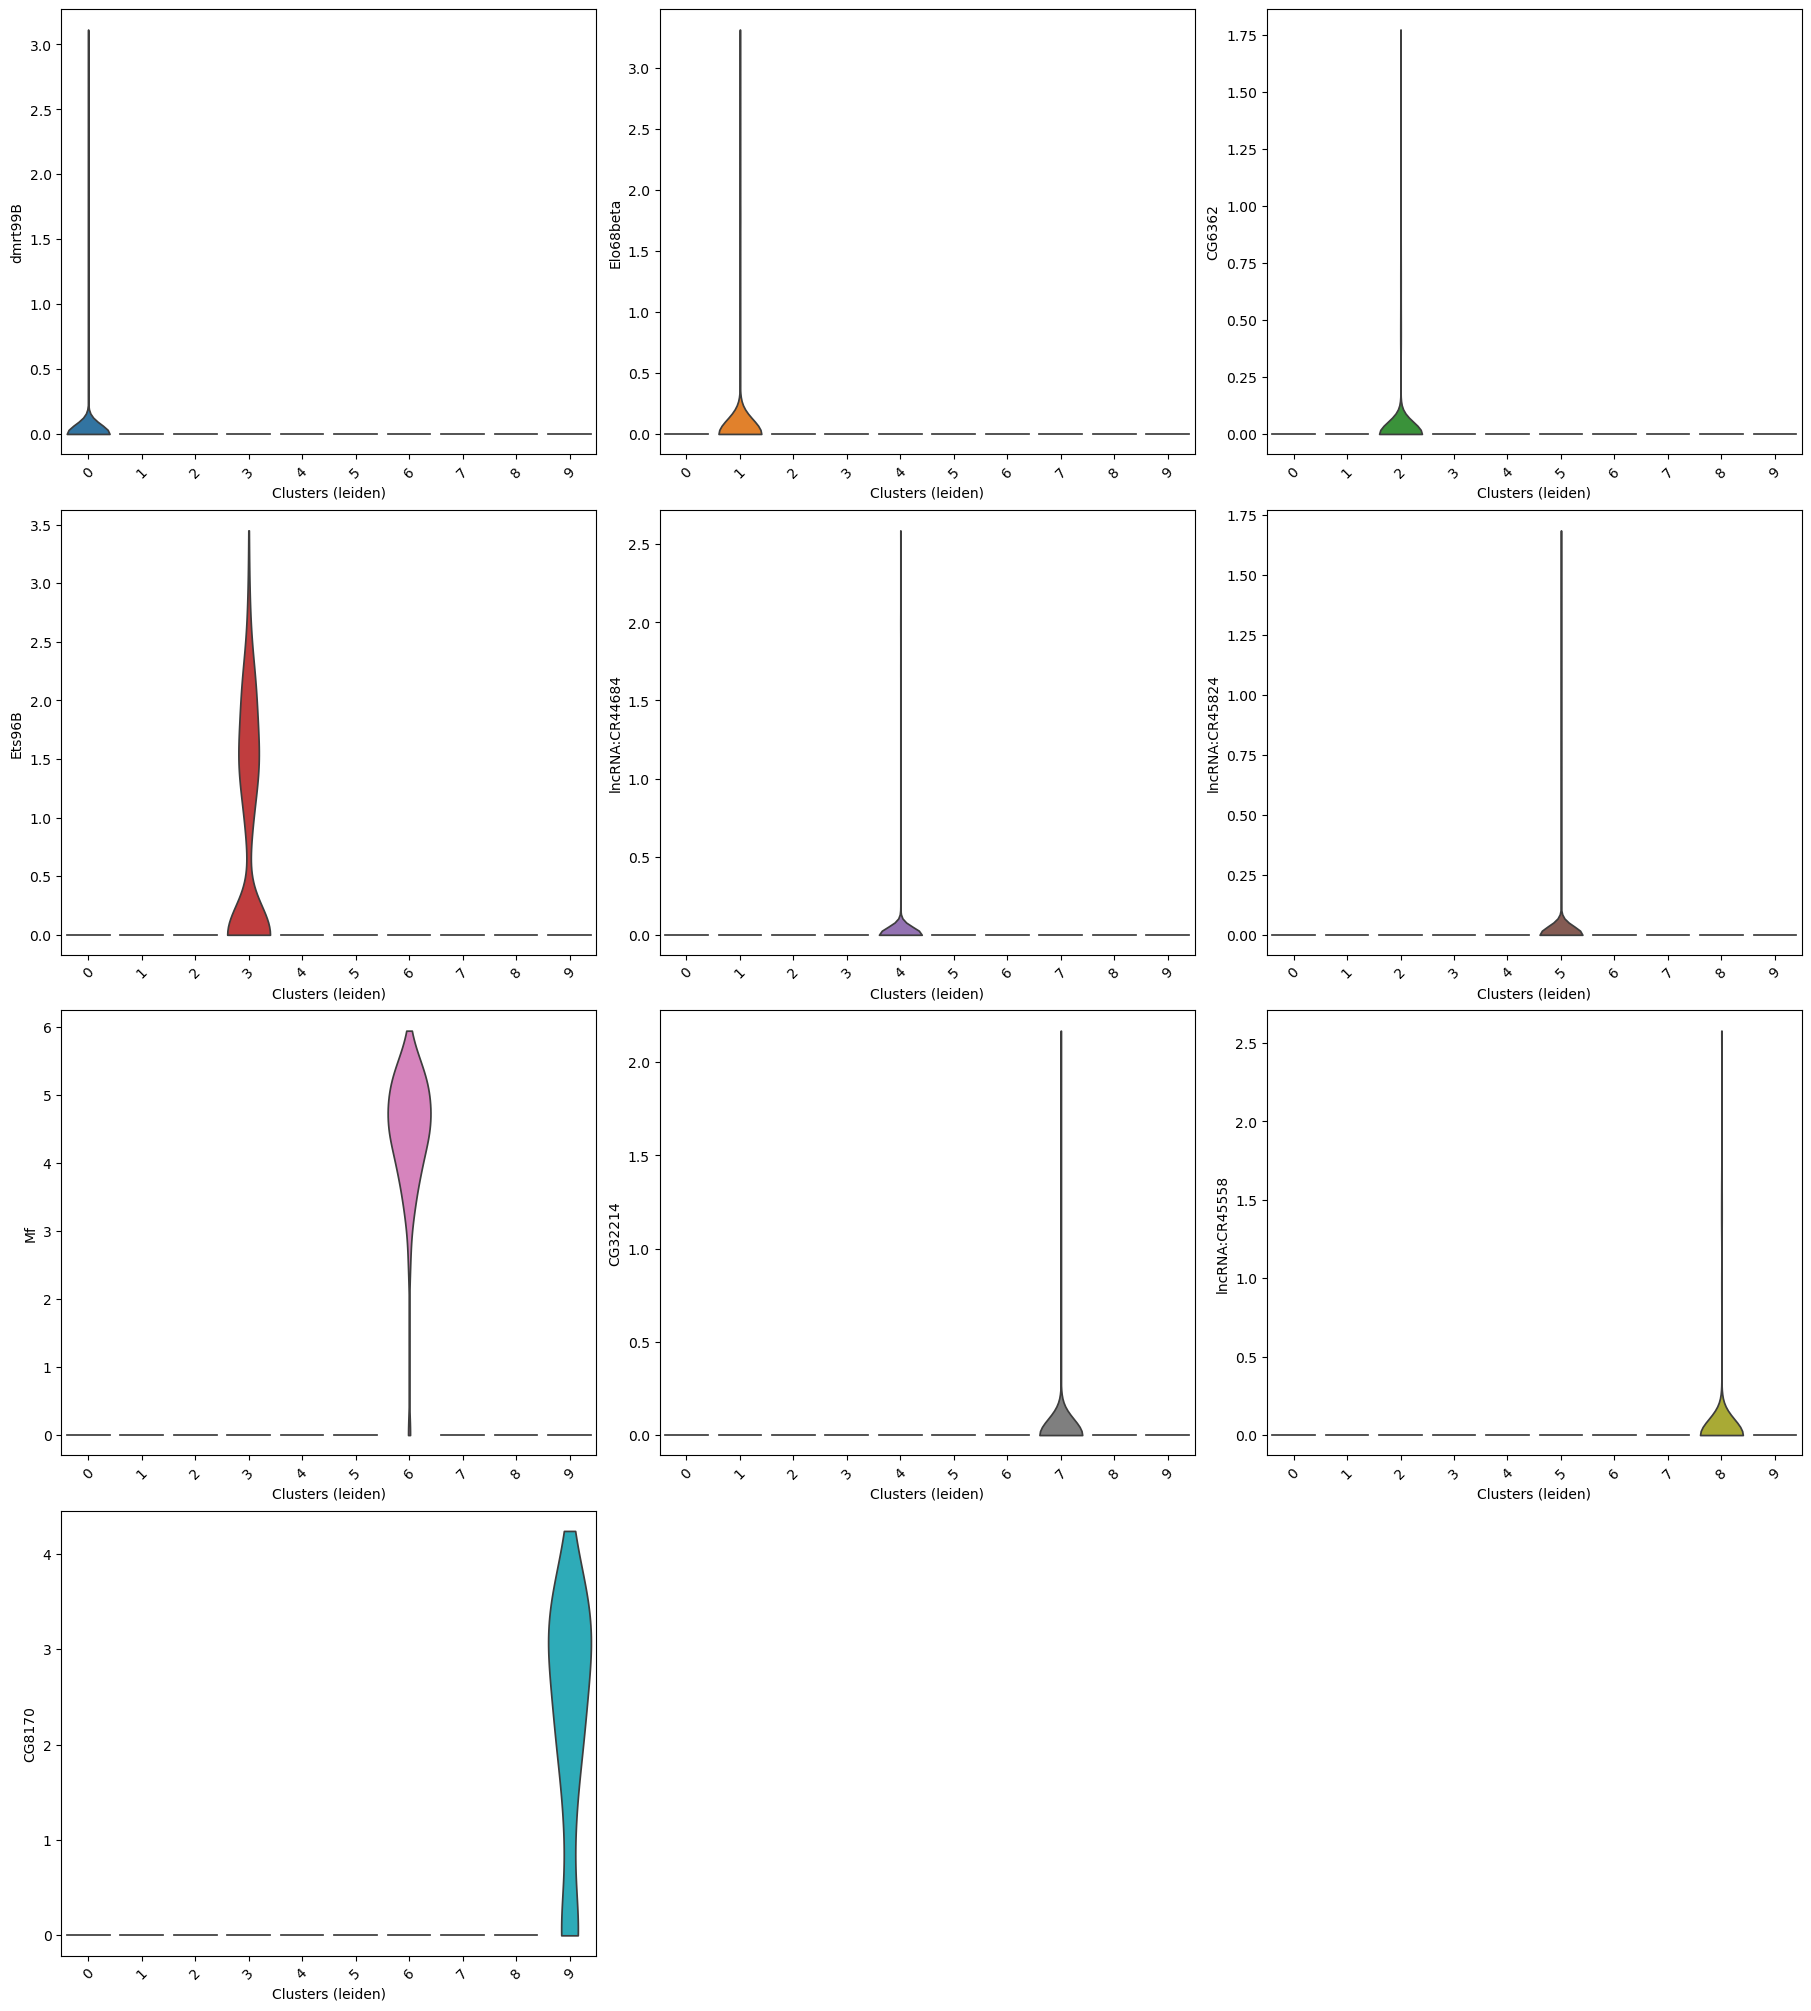

In [ ]:
ncols = 3
nrows = (len(top_genes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows), constrained_layout=True)
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i, gene in enumerate(top_genes):
    sc.pl.violin(
        data,
        keys=gene,
        groupby="leiden",
        ax=axes[i],
        show=False,
        stripplot=False,
        rotation=45
    )
    for coll in axes[i].collections:
        coll.set_facecolor("lightgray")
        coll.set_edgecolor("dimgray")
    axes[i].set_xlabel("Clusters (leiden)")

for j in range(len(top_genes), len(axes)):
    axes[j].axis("off")

plt.show()

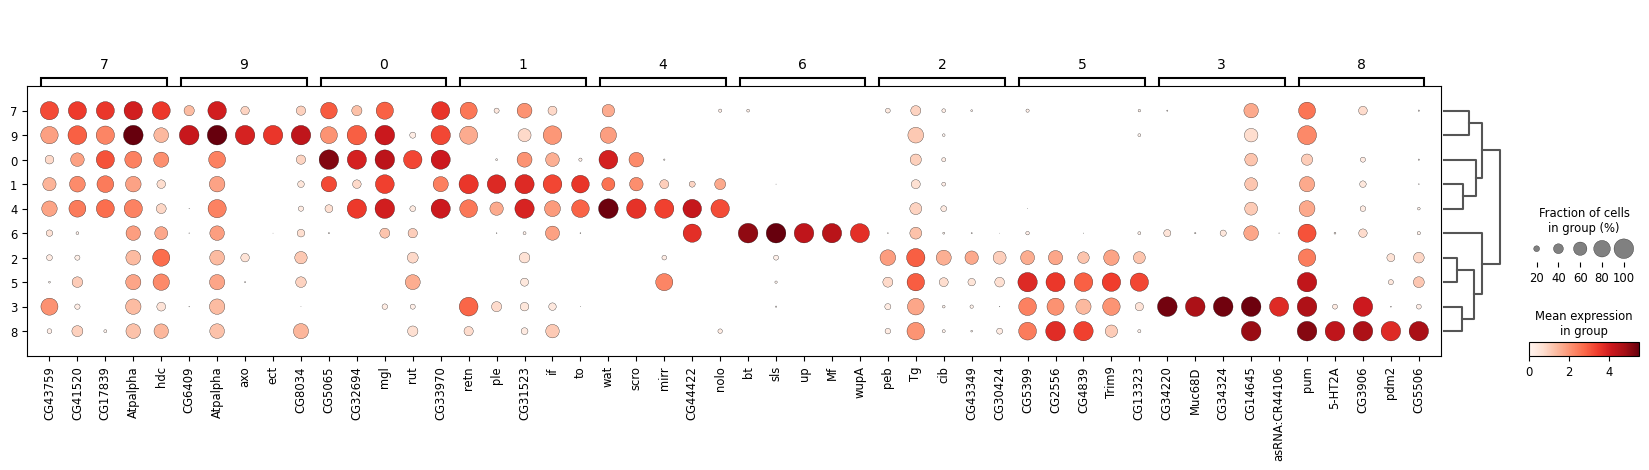

In [81]:
sc.pl.rank_genes_groups_dotplot(data, n_genes=5)

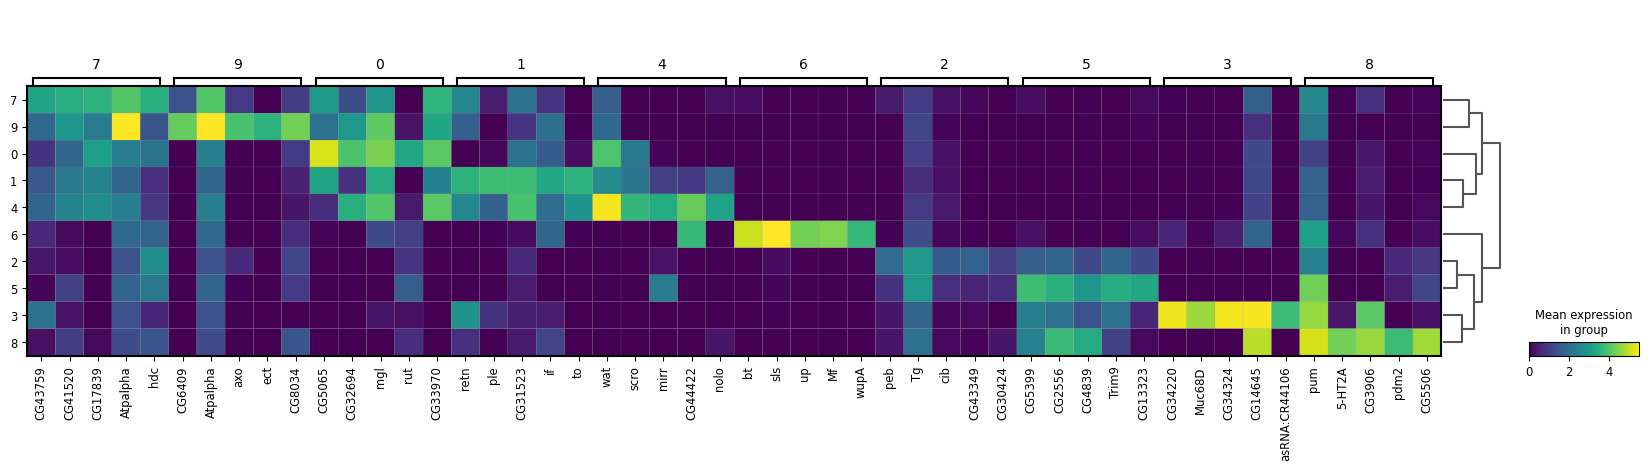

In [82]:
sc.pl.rank_genes_groups_matrixplot(data, n_genes=5)